# Soft Clustering with Gaussian Mixture Models


## From Hard to Soft Clustering

[![](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tools4ds/DS701-Materials-FA26/blob/main/jupyter_notebooks/06-Clustering-III-GMM-EM.ipynb)

In [1]:
#| echo: false
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

<!--
![](figs/L09-MultivariateNormal.png)
-->


__So far,__ we have seen how to cluster objects using $k$-means: 

* In $k$-means clustering every object is assigned to a **single** cluster. 
* This is called __hard__ assignment.


And then we looked at **hierarchical clustering**: 

* In hierarchical clustering, objects are grouped into a tree of clusters.
* Clusters are nested: each cluster is fully contained in the one above it.


However, there may be cases where we either __cannot__ use hard assignments or we do not __want__ to do it.

In particular, we might have reason to believe that the best description of the data is a set of __overlapping__ clusters.


# Overlapping Clusters

## Income Level Example

Consider a population in terms of a simple __binary__ income level: higher or lower than some threshold.

How might we model such a population in terms of the single feature __age__?

## Income Level Sampling

Let's sample 20,000 _above income threshold_ individuals and 20,000 _below income threshold_ individuals. 

From this sample we get have the following histograms.

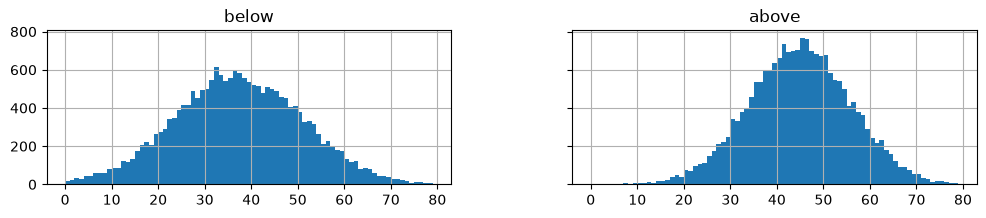

In [2]:
#| fig-align: center
# original inspiration for this example from
# https://www.cs.cmu.edu/~./awm/tutorials/gmm14.pdf
from scipy.stats import multivariate_normal
np.random.seed(4)
df = pd.DataFrame(multivariate_normal.rvs(mean = np.array([37, 45]), cov = np.diag([196, 121]), size = 20000),
                   columns = ['below', 'above'])
df.hist(bins = range(80), sharex = True, sharey=True, figsize=(12, 2))
plt.show()

We find that ages of the below income threshold set have mean $\mu=37$ with standard deviation $\sigma=14$, while the ages of the above income threshold set have mean $\mu=45$ with standard deviation $\sigma=11$.

## Income Level by Age

We can plot gaussian distributions for the two income levels.

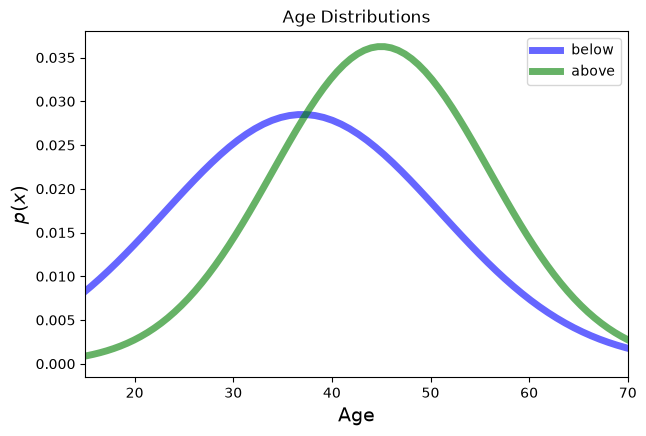

In [3]:
#| fig-align: center
from scipy.stats import norm
plt.figure(figsize=(7, 4.5))
x = np.linspace(norm.ppf(0.001, loc = 37, scale = 14), norm.ppf(0.999, loc = 37, scale = 14), 100)
plt.plot(x, norm.pdf(x, loc = 37, scale = 14),'b-', lw = 5, alpha = 0.6, label = 'below')
x = np.linspace(norm.ppf(0.001, loc = 45, scale = 11), norm.ppf(0.999, loc = 45, scale = 11), 100)
plt.plot(x, norm.pdf(x, loc = 45, scale = 11),'g-', lw = 5, alpha = 0.6, label = 'above')
plt.xlim([15, 70])
plt.xlabel('Age', size=14)
plt.legend(loc = 'best')
plt.title('Age Distributions')
plt.ylabel(r'$p(x)$', size=14)
plt.show()

## Soft Clustering


* two overlapping clusters.

* given some particular individual at a given age, say 25, we cannot say for sure which cluster they belong to.  

* use _probability_ to quantify our uncertainty about cluster membership.

* Individual belongs to the cluster 1 with some probability $p_1$ and the cluster 2 with a different probability $p_2$.


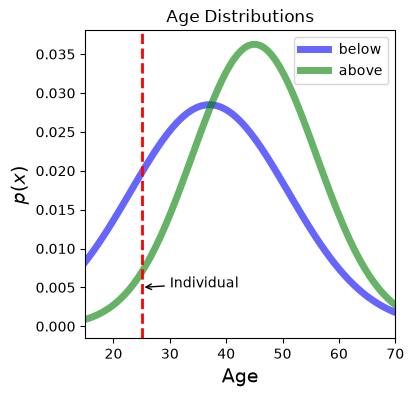

In [4]:
#| fig-align: center
#| echo: false
from scipy.stats import norm
plt.figure(figsize=(4, 4))
x = np.linspace(norm.ppf(0.001, loc = 37, scale = 14), norm.ppf(0.999, loc = 37, scale = 14), 100)
plt.plot(x, norm.pdf(x, loc = 37, scale = 14),'b-', lw = 5, alpha = 0.6, label = 'below')
x = np.linspace(norm.ppf(0.001, loc = 45, scale = 11), norm.ppf(0.999, loc = 45, scale = 11), 100)
plt.plot(x, norm.pdf(x, loc = 45, scale = 11),'g-', lw = 5, alpha = 0.6, label = 'above')
plt.xlim([15, 70])
plt.xlabel('Age', size=14)
plt.legend(loc = 'best')
plt.title('Age Distributions')
plt.ylabel(r'$p(x)$', size=14)
plt.axvline(x=25, color='r', linestyle='--', linewidth=2)
plt.annotate('Individual', xy=(25, 0.005), xytext=(30, 0.005), arrowprops=dict(arrowstyle='->'))
plt.show()

* Naturally we expect the probabilities to sum up to 1.

* This is called __soft assignment,__ and a clustering using this principle is called __soft clustering.__


## Conditional Probability

More formally, we say that an object can belong to each particular cluster with some probability, such that the sum of the probabilities adds up to 1 for each object. 

For example, assuming that we have two clusters $C_1$ and $C_2$, we can have that an object $x_1$ belongs to $C_1$ with probability $0.3$ and to $C_2$ with probability $0.7$.

Note that the distribution over $C_1$ and $C_2$ only refers to object $x_1$.


Thus, it is a __conditional__ probability:

$$
\begin{align*}
P(C_1 \,|\, x_1 = 25) &= 0.3, \\
P(C_2 \,|\, x_1 = 25) &= 0.7.
\end{align*}
$$



And to return to our previous example

$$
P(\text{above income threshold}\,|\,\text{age 25}) + P(\text{below income threshold}\,|\,\text{age 25}) = 1.
$$


# GMM Overview

Our goal with Gaussian mixture models (GMMs) is to show how to compute the probabilities that a data point belongs to a particular cluster.

The main ideas behind GMMs are

- Assume each cluster is normally distributed
- Use the Expectation Maximization (EM) algorithm to iteratively determine:
    * the parameters of the Gaussian clusters using _MLE_, and
    * the probabilities that a data point belongs to a particular cluster

We will see that GMMs are better suited for clustering non-spherical distributions of points.

GMMs build directly on _maximum likelihood estimation_ from [Probabilistic Modeling](./05-Probabilistic-Modeling.qmd), so we start with a brief callback.

# Recall: Maximum Likelihood Estimation

## MLE in One Slide

Recall from [Probabilistic Modeling](./05-Probabilistic-Modeling.qmd):

* A distribution is specified by its parameters $\boldsymbol{\theta}$; for a Gaussian, $\boldsymbol{\theta} = (\mu, \sigma^2)$.
* The **likelihood** of i.i.d. samples $x_1, \ldots, x_N$ is $L(\boldsymbol{\theta}) = \prod_{n=1}^{N} p(x_n \vert \boldsymbol{\theta})$; the **maximum likelihood estimate** is the $\boldsymbol{\theta}$ that maximizes it (equivalently, the log-likelihood $\ell = \log L$).
* For a Gaussian, setting $\nabla_{\mu}\ell = 0$ and $\nabla_{\sigma}\ell = 0$ gives closed-form estimates:


$$
\begin{align*}
\bar{\mu} &= \frac{1}{N}\sum_{n=1}^{N} x_{n} \quad\text{(sample mean)}, \\
\bar{\sigma}^2 &= \frac{1}{N}\sum_{n=1}^{N}(x_{n} - \bar{\mu})^{2} \quad\text{(sample variance)}.
\end{align*}
$$

The full derivation is in [this appendix](05A-Appendix-Derive-MLE-params-for-gaussian.qmd).


## From One Gaussian to a Mixture

Keep those two formulas in front of you -- they reappear inside EM.

* A GMM extends the single Gaussian to a **mixture** of $K$ Gaussians, each with its own $\boldsymbol{\mu}_k, \Sigma_k$ and a mixing weight $\pi_k$.
* We would like to estimate all of these by MLE, exactly as above.
* But the mixture likelihood has a **sum inside the log** and no closed-form maximizer.
* That is why we need the **Expectation-Maximization (EM)** algorithm -- and, as we will see, its M-step is just the Gaussian MLE formulas, weighted by soft cluster assignments.


# Gaussian Mixture Models

## Univariate Gaussians

In GMMs we assume that each of our clusters follows a Gaussian (normal) distribution with their own parameters. 

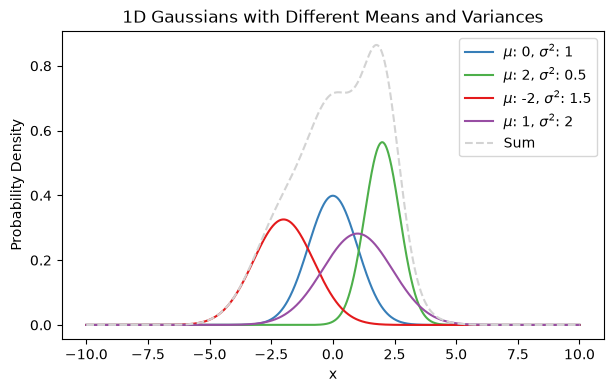

In [5]:
#| fig-align: "center"
#| 
import numpy as np
import matplotlib.pyplot as plt

# Define the parameters for the 4 Gaussians
params = [
    {"mean": 0, "variance": 1, "color": "#377eb8"},  # Blue
    {"mean": 2, "variance": 0.5, "color": "#4daf4a"},  # Green
    {"mean": -2, "variance": 1.5, "color": "#e41a1c"},  # Red
    {"mean": 1, "variance": 2, "color": "#984ea3"}  # Purple
]

# Generate x values
x = np.linspace(-10, 10, 1000)

total = np.zeros_like(x)

plt.figure(figsize=(7, 4))

# Plot each Gaussian
for param in params:
    mean = param["mean"]
    variance = param["variance"]
    color = param["color"]
    
    # Calculate the Gaussian
    y = (1 / np.sqrt(2 * np.pi * variance)) * np.exp(- (x - mean)**2 / (2 * variance))
    
    # Plot the Gaussian
    plt.plot(x, y, color=color, label=f"$\\mu$: {mean}, $\\sigma^2$: {variance}")
    total += y

plt.plot(x, total, color="lightgray", linestyle="--", label="Sum")

# Add legend
plt.legend()

# Add title and labels
plt.title("1D Gaussians with Different Means and Variances")
plt.xlabel("x")
plt.ylabel("Probability Density")

# Show the plot
plt.show()

## Multivariate Gaussians

Given data points $\mathbf{x}\in\mathbb{R}^{d}$, i.e., $d$-dimensional points, then we use the multivariate Gaussian to describe the clusters. The formula for the multivariate Gaussian is

$$
f(\mathbf{x}\vert \boldsymbol{\mu}, \Sigma) = \frac{1}{(2\pi)^{d/2}\vert \Sigma \vert^{1/2}}e^{-\frac{1}{2}(\mathbf{x}-\boldsymbol{\mu})^T\Sigma^{-1}(\mathbf{x}-\boldsymbol{\mu})},
$$

where $\Sigma\in\mathbb{R}^{d\times d}$ is the covariance matrix, $\vert \Sigma\vert$, denote the determinant of $\Sigma$, and $\boldsymbol{\mu}$ is the $d$-dimensional vector of expected values.

The covariance matrix is the multidimensional analog of the variance. It 
determines the extent to which vector components are correlated.

See [here](06A-Appendix-Cov-Matrix-in-MV-Gaussians.qmd) for a refresher on the covariance matrix.

## Notation

The notation $x \sim \mathcal{N}(\mu, \sigma^2)$ is used to denote a _univariate_ random variable that is normally 
distributed with expected value $\mu$ and variance $\sigma^{2}.$

The notation $\mathbf{x} \sim \mathcal{N}(\boldsymbol{\mu}, \Sigma)$ is used to denote a _multivariate_
random variable that is normally distributed with mean $\boldsymbol{\mu}$ and covariance matrix $\Sigma$.

## Multivariate Example: Cars

To illustrate a particular model, let us consider the properties of cars produced in the US, Europe, and Asia^[A. Moore, "Clustering with Gaussian Mixtures", [lecture notes](https://autonlab.org/assets/tutorials/gmm14.pdf)].

For example, let's say we are looking to classify cars based on their model year and miles per gallon (mpg).  

<!-- image credit: https://www.cs.cmu.edu/~./awm/tutorials/gmm14.pdf -->
![](figs/L09-multivariate-example.png)

It seems that the data can be described (roughly) as a mixture of __three__ __multivariate__ Gaussian distributions.

# Expectation-Maximization for Gaussian Mixture Models

## The Gaussian Mixture Model

We observe $n$ data points $x_1, \ldots, x_n$ in $\mathbb{R}^d$ that appear to come from $K$ clusters.

A Gaussian Mixture Model (GMM) assumes each data point is generated by the following process:

1. Choose a cluster $k \in \{1, 2, \ldots, K\}$ with probability $\pi_k$ (where $\sum_{k=1}^K \pi_k = 1$)
2. Generate the point from that cluster's Gaussian: $x_i \sim \mathcal{N}(\mu_k, \Sigma_k)$

The probability density of observing point $x_i$ is:

$$
p(x_i \mid \theta) = \sum_{k=1}^{K} \pi_k \mathcal{N}(x_i \mid \mu_k, \Sigma_k)
$$

where $\theta = \{\pi_k, \mu_k, \Sigma_k\}_{k=1}^K$ are the parameters we need to estimate.

## The Log-Likelihood Challenge

Assuming i.i.d. data, the log-likelihood is

$$
\ell(\theta) = \log \prod_{i=1}^{n} p(x_i \mid \theta) = \sum_{i=1}^{n} \log \left( \sum_{k=1}^{K} \pi_k \mathcal{N}(x_i \mid \mu_k, \Sigma_k) \right).
$$

- In [Probabilistic Modeling](./05-Probabilistic-Modeling.qmd) the log turned a product into a sum of simple terms, and the derivative of each term gave a closed-form estimate.
- Here there is a **sum inside the log**. The terms do not separate.
- Setting the gradient to zero gives a system of coupled equations with no closed-form solution.


## EM in One Slide

Let $z_i \in \{1, \ldots, K\}$ be the cluster that generated $x_i$. We never observe it: $z_i$ is a **latent variable**.

- If we **knew every $z_i$**, estimating $\theta$ would be lecture 05 again: $\mu_k$ is the mean of the points in cluster $k$, $\Sigma_k$ their covariance, $\pi_k$ their fraction of the data.
- If we **knew $\theta$**, we could compute how probable each cluster is for each point. That is Bayes' rule.
- We know neither. This is a classic 🐓 and 🥚 problem.


**Expectation-Maximization (EM)** breaks the loop by alternating:

1. **E-step:** with the current $\theta$, compute $\gamma_{ik} = P(z_i = k \mid x_i, \theta)$ for every point and every cluster. This is a *soft* assignment.
2. **M-step:** treat the $\gamma_{ik}$ as fractional memberships and re-estimate $\theta$ with the lecture-05 formulas, weighted.

Each round can only increase $\ell(\theta)$, so the iteration converges (to a local maximum).


Let's do the E-step by hand for a single point first.


## Bayes' Rule for One Point

Back to the income example, this time with the parameters **known**:

* $C_1$ = below threshold: $\mu_1 = 37,\ \sigma_1 = 14$
* $C_2$ = above threshold: $\mu_2 = 45,\ \sigma_2 = 11$
* mixing weights $\pi_1 = \pi_2 = 0.5$, since we sampled 20,000 of each

One individual is age $x = 25$. What is $P(C_2 \mid x = 25)$, the probability they are above the threshold?

Bayes' rule:

$$
P(C_2 \mid x) = \frac{P(x \mid C_2)\, P(C_2)}{P(x)} = \frac{\mathcal{N}(x \mid \mu_2, \sigma_2^2)\; \pi_2}{P(x)},
$$

and the law of total probability gives the denominator:

$$
P(x) = P(x \mid C_1)\,P(C_1) + P(x \mid C_2)\,P(C_2) = \sum_{k=1}^{2} \pi_k \, \mathcal{N}(x \mid \mu_k, \sigma_k^2).
$$

The denominator is the GMM density from two slides ago.


## Bayes' Rule for One Point, Illustrated

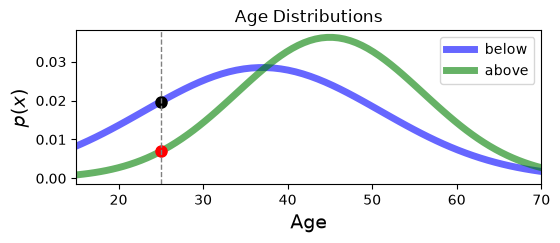

In [6]:
#| fig-align: "center"
plt.figure(figsize=(6, 2))
x = np.linspace(norm.ppf(0.001, loc = 37, scale = 14), norm.ppf(0.999, loc = 37, scale = 14), 100)
plt.plot(x, norm.pdf(x, loc = 37, scale = 14),'b-', lw = 5, alpha = 0.6, label = 'below')
plt.plot(25, norm.pdf(25, loc = 37, scale = 14), 'ko', markersize = 8)
x = np.linspace(norm.ppf(0.001, loc = 45, scale = 11), norm.ppf(0.999, loc = 45, scale = 11), 100)
plt.plot(x, norm.pdf(x, loc = 45, scale = 11),'g-', lw = 5, alpha = 0.6, label = 'above')
plt.plot(25, norm.pdf(25, loc = 45, scale = 11), 'ro', markersize = 8)
plt.axvline(x=25, color='gray', linestyle='--', linewidth=1)
plt.xlim([15, 70])
plt.xlabel('Age', size=14)
plt.legend(loc = 'best')
plt.title('Age Distributions')
plt.ylabel(r'$p(x)$', size=14)
plt.show()

$$
P(\text{above}\,|\,\text{age 25}) = \frac{\text{red} \cdot \pi_2}{\text{black} \cdot \pi_1 + \text{red} \cdot \pi_2},
\qquad
\text{red} = \mathcal{N}(25 \mid 45, 11^2),\quad \text{black} = \mathcal{N}(25 \mid 37, 14^2).
$$

In [7]:
black = norm.pdf(25, loc=37, scale=14)   # density under 'below'
red   = norm.pdf(25, loc=45, scale=11)   # density under 'above'
p_above = red * 0.5 / (black * 0.5 + red * 0.5)
print(f'P(above | age 25) = {p_above:.3f},  P(below | age 25) = {1 - p_above:.3f}')

P(above | age 25) = 0.260,  P(below | age 25) = 0.740


So this 25-year-old belongs to "above" with probability 0.26 and to "below" with probability 0.74. That pair of numbers is a **soft assignment**.

In EM notation it is one row of the responsibilities: $\gamma_{i,\text{above}} = 0.26$ and $\gamma_{i,\text{below}} = 0.74$.


## E-Step: Compute Responsibilities

You just computed one entry. The E-step does this for **every** point $i$ and **every** cluster $k$, using the current parameters $\theta^{(t)}$:

$$
\gamma_{ik} = \frac{\pi_k \, \mathcal{N}(x_i \mid \mu_k, \Sigma_k)}{\sum_{j=1}^{K} \pi_j \, \mathcal{N}(x_i \mid \mu_j, \Sigma_j)}
$$

- $\gamma_{ik}$ is the **responsibility** that cluster $k$ takes for point $i$
- Each row sums to 1: $\sum_{k=1}^{K} \gamma_{ik} = 1$, a soft assignment
- The result is an $n \times K$ matrix of responsibilities

## M-Step: Update Parameters

Given the responsibilities, let $N_k = \sum_{i=1}^{n} \gamma_{ik}$, the *effective* number of points in cluster $k$. Then

$$
\mu_k = \frac{1}{N_k}\sum_{i=1}^{n} \gamma_{ik}\, x_i, \qquad
\Sigma_k = \frac{1}{N_k}\sum_{i=1}^{n} \gamma_{ik}\,(x_i - \mu_k)(x_i - \mu_k)^T, \qquad
\pi_k = \frac{N_k}{n}.
$$

- Compare with the MLE formulas from lecture 05: same sample mean and sample covariance, except that every point contributes to **every** cluster, weighted by how responsible that cluster is for it.
- If every $\gamma_{ik}$ were exactly 0 or 1, these collapse to per-cluster means and covariances. That is the $k$-means update.


## Watch It Run

Let's implement EM from scratch for the 1-D age data. The whole algorithm is three short functions.

In [8]:
ages = np.r_[df['below'], df['above']]     # 40,000 ages; the labels are thrown away

def e_step(x, pi, mu, sigma):
    # responsibilities: n x K, each row sums to 1
    dens = np.column_stack([pi[k] * norm.pdf(x, mu[k], sigma[k]) for k in range(len(pi))])
    return dens / dens.sum(axis=1, keepdims=True)

def m_step(x, gamma):
    # weighted MLE: the lecture-05 formulas with responsibilities as weights
    N_k = gamma.sum(axis=0)
    pi = N_k / len(x)
    mu = (gamma * x[:, None]).sum(axis=0) / N_k
    sigma = np.sqrt((gamma * (x[:, None] - mu)**2).sum(axis=0) / N_k)
    return pi, mu, sigma

def log_likelihood(x, pi, mu, sigma):
    mixture = sum(pi[k] * norm.pdf(x, mu[k], sigma[k]) for k in range(len(pi)))
    return np.log(mixture).sum()

Start from deliberately bad guesses: clusters far too narrow and far too far apart.

In [9]:
pi, mu, sigma = np.array([0.5, 0.5]), np.array([20.0, 60.0]), np.array([5.0, 5.0])

history = []
for t in range(100):
    history.append((pi, mu, sigma, log_likelihood(ages, pi, mu, sigma)))
    gamma = e_step(ages, pi, mu, sigma)          # E-step
    pi, mu, sigma = m_step(ages, gamma)          # M-step
history.append((pi, mu, sigma, log_likelihood(ages, pi, mu, sigma)))

## Watch It Run, cont.

Top row: the two weighted components $\pi_k \mathcal{N}(x \mid \mu_k, \sigma_k^2)$ ([blue]{style="color: #0000ff"}, [green]{style="color: #008000"}) over a histogram ([gray]{style="color: gray"}) of the data. Bottom row: the responsibility $\gamma_{i,\text{above}}$ as a function of age.

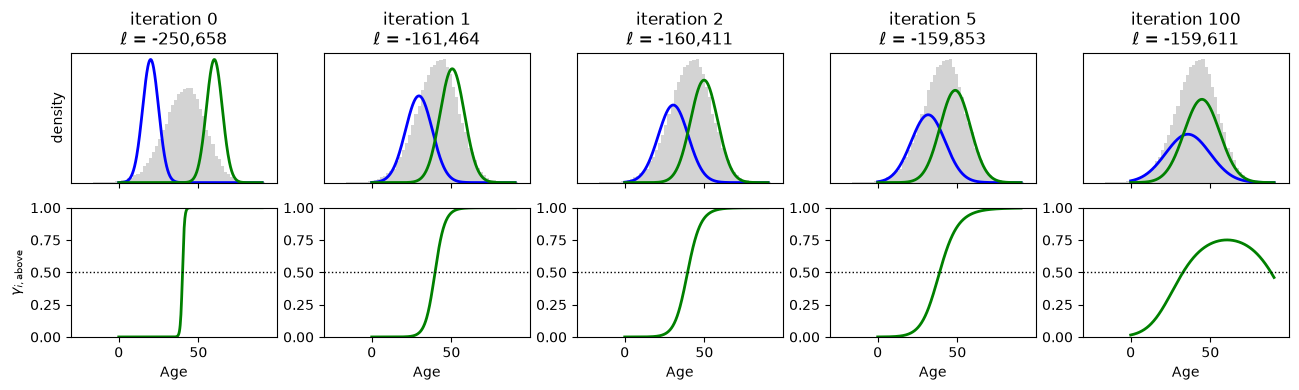

In [10]:
#| code-fold: true
#| fig-align: "center"
snapshots = [0, 1, 2, 5, 100]
grid = np.linspace(0, 90, 400)
fig, axes = plt.subplots(2, len(snapshots), figsize=(13, 4), sharex=True)
for col, t in enumerate(snapshots):
    pi_t, mu_t, sigma_t, ll_t = history[t]
    ax = axes[0, col]
    ax.hist(ages, bins=60, density=True, color='lightgray')
    for k, c in enumerate(['b', 'g']):
        ax.plot(grid, pi_t[k] * norm.pdf(grid, mu_t[k], sigma_t[k]), c, lw=2)
    ax.set_title(f'iteration {t}\n$\\ell$ = {ll_t:,.0f}')
    ax.set_yticks([])
    ax = axes[1, col]
    ax.plot(grid, e_step(grid, pi_t, mu_t, sigma_t)[:, 1], 'g', lw=2)
    ax.axhline(0.5, color='k', ls=':', lw=1)
    ax.set_ylim(0, 1)
    ax.set_xlabel('Age')
axes[0, 0].set_ylabel('density')
axes[1, 0].set_ylabel(r'$\gamma_{i,\mathrm{above}}$')
plt.tight_layout()
plt.show()

- The first iteration does most of the work: the components jump to the data and the soft boundary moves to where the two curves cross.
- After that the changes are small. The log-likelihood never decreases.
- By iteration 100 the boundary is no longer a single cutoff: the wider "below" Gaussian wins back the oldest ages from the narrower "above" one. A soft assignment captures that; a threshold on age cannot.


## Watch It Run, cont.

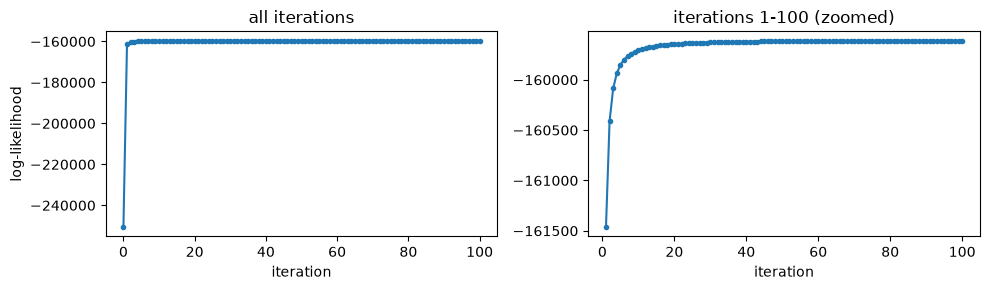

In [11]:
#| code-fold: true
#| fig-align: "center"
lls = [h[3] for h in history]
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].plot(lls, 'o-', ms=3)
ax[0].set_xlabel('iteration'); ax[0].set_ylabel('log-likelihood'); ax[0].set_title('all iterations')
ax[1].plot(range(1, 101), lls[1:], 'o-', ms=3)
ax[1].set_xlabel('iteration'); ax[1].set_title('iterations 1-100 (zoomed)')
plt.tight_layout()
plt.show()

In [12]:
truth = (np.array([0.5, 0.5]), np.array([37, 45]), np.array([14, 11]))
print(f'EM after 100 iterations: pi={np.round(pi, 2)}, mu={np.round(mu, 1)}, sigma={np.round(sigma, 1)},  ll={log_likelihood(ages, pi, mu, sigma):,.1f}')
print(f'Generating parameters:   pi={truth[0]}, mu={truth[1]}, sigma={truth[2]},  ll={log_likelihood(ages, *truth):,.1f}')

EM after 100 iterations: pi=[0.42 0.58], mu=[35.9 44.7], sigma=[13.9 11.1],  ll=-159,611.4
Generating parameters:   pi=[0.5 0.5], mu=[37 45], sigma=[14 11],  ll=-159,614.1


EM's parameters have a slightly **higher** likelihood than the ones that generated the data, yet they are not the same. Two Gaussians that overlap this much are hard to tell apart even with 40,000 samples: many nearby mixtures fit almost equally well, so the likelihood is nearly flat and EM crawls along it.

Keep this in mind for the overlapping-clusters example later.


## Initialization

- Initialize the $K$ means $\mu_k$ randomly, or with $k$-means (sklearn's default, `init_params='kmeans'`)
- Initialize covariances $\Sigma_k$, often as identity matrices or the sample covariance
- Initialize mixing weights $\pi_k = \frac{1}{K}$

EM finds a **local** maximum, so the result depends on this choice. In practice you run several initializations and keep the one with the highest log-likelihood (`n_init` in sklearn).

## Iteration and Convergence

Alternate E and M steps. The log-likelihood is guaranteed not to decrease, so monitor it and stop when it stops moving:

- **Log-likelihood:** $\lvert \ell^{(t)} - \ell^{(t-1)} \rvert < \text{tol}$, with $\text{tol}$ small (e.g. $10^{-4}$), or
- **Parameters:** $\lVert \theta^{(t)} - \theta^{(t-1)} \rVert_2 < \text{tol}$, and always
- **Iteration cap:** $t > \text{max\_iterations}$ (e.g. 100), for cases that converge slowly or never fully stabilize.


The tolerance matters. On the age data above, sklearn's default tolerance stops after about 8 iterations, well inside the flat region.


## Why Does Alternating Work?

The algorithm above is what everyone implements. Here is what each step is doing to the likelihood, and where the closed-form updates come from.

If the assignments $z_i$ were known, the **complete-data** log-likelihood would be

$$
\log p(X, Z \mid \theta) = \sum_{i=1}^{n} \sum_{k=1}^{K} \mathbb{1}(z_i = k) \left[ \log \pi_k + \log \mathcal{N}(x_i \mid \mu_k, \Sigma_k) \right].
$$

There is no sum inside the log: it separates by cluster and maximizes in closed form.

- **E-step:** we don't know $\mathbb{1}(z_i = k)$, so we replace it with its expected value under the current parameters, $\mathbb{E}\!\left[\mathbb{1}(z_i = k) \mid x_i, \theta^{(t)}\right] = P(z_i = k \mid x_i, \theta^{(t)}) = \gamma_{ik}$.
- **M-step:** maximize the resulting *expected* complete-data log-likelihood. The $\gamma_{ik}$ are constants in it, so the maximizer is exactly the weighted MLE formulas.


Derivations: [the complete-data likelihood](06B-Appendix-complete-data-likelihood.qmd), [the E-step](06C-Appendix-Derive-the-E-step.qmd) and [the M-step](06D-Appendix-Derive-the-M-step.qmd). Try them yourself first.
<!-- Enable when 06E is published: and [why $\ell$ never decreases](06E-Appendix-Why-EM-Never-Decreases.qmd) -->


## Storage and Computational Costs

It is important to be aware of the computational costs of our algorithm.

Storage costs:

- There are $n$ $d$-dimensional points
- There are $K$ clusters
- There are $n\times K$ responsibilities $\gamma_{ik}$
- There are $K$ $d$-dimensional cluster centers $\mu_k$
- There are $K$ $d\times d$ covariance matrices $\Sigma_k$
- There are $K$ weights $\pi_k$

Computational costs:

- Computing each $\gamma_{ik}$ requires a sum of $K$ evaluations of the Gaussian PDF.
- Updating $\mu_k$ requires $n$ vector summations
- Updating $\Sigma_k$ requires $n$ outer products
- Updating $\pi_k$ requires a division (given $N_k$)


## k-means vs GMMs

Let's pause for a minute and compare GMM/EM with $k$-means.

__GMM/EM__

1. Initialize randomly or using some rule
1. Compute the probability that each point belongs in each cluster
1. Update the clusters (weights, means, and variances).
1. Repeat 2-3 until convergence.

__$k$-means__

1. Initialize randomly or using some rule
1. Assign each point to a single cluster
1. Update the clusters (means).
1. Repeat 2-3 until convergence.


---

From a practical standpoint, the main difference is that in GMMs, data points do not belong to a __single__ cluster, but have some probability of belonging to __each__ cluster.

In other words, as stated previously, GMMs use soft assignment.

For that reason, GMMs are also sometimes called __soft $k$-means.__

---

However, there is also an important conceptual difference.

The GMM starts by making an __explicit assumption__ about how the data were generated.

It says: "the data came from a collection of multivariate Gaussians."

We made no such assumption when we came up with the $k$-means problem. In that case, we simply defined an objective function and declared that it was a good one.

Nonetheless, it appears that we were making a sort of Gaussian assumption when we formulated the $k$-means objective function. However, __it wasn't explicitly stated.__

The point is that because the GMM makes its assumptions explicit, we can

* examine them and think about whether they are valid, and
* replace them with different assumptions if we wish.

For example, it is perfectly valid to replace the Gaussian assumption with some other probability distribution.  As long as we can estimate the parameters of such distributions from data (e.g., have MLEs), we can use EM in that case as well.

## Versatility of EM

A final statement about EM generally. EM is a versatile algorithm that can be used in many other settings.  What is the main idea behind it?

Notice that the problem definition only required that we find the clusters, i.e., the $(\pi_k, \mu_k, \Sigma_k)$.

However, the EM algorithm posited that we should find as well the $P(z_i = k \mid x_i) = \gamma_{ik}$, the probability that each point is a member of each cluster.

This is the true heart of what EM does.

By __adding variables__ to the problem, the latent $z_i$ and their posteriors $\gamma_{ik}$, it finds a way to make the problem solvable.

Those latent variables don't show up in the final answer.

# Examples

## Example 1

sklearn's `GaussianMixture` runs exactly the E- and M-steps we just wrote, in $d$ dimensions with full covariance matrices $\Sigma_k$. Here is an example using **GMM**.

We're going to create two clusters, one spherical, and one highly skewed.


In [13]:
# Number of samples of larger component
n_samples = 1000

# C is a transfomation that will make a heavily skewed 2-D Gaussian
C = np.array([[0.1, -0.1], [1.7, .4]])

print(f'The covariance matrix of our skewed cluster will be:\n {C.T@C}')

The covariance matrix of our skewed cluster will be:
 [[2.9  0.67]
 [0.67 0.17]]


In [14]:
import warnings
warnings.filterwarnings('ignore')

rng = np.random.default_rng(0)

# now we construct a data matrix that has n_samples from the skewed distribution,
# and n_samples/2 from a symmetric distribution offset to position (-4, 2)
X = np.r_[(rng.standard_normal((n_samples, 2)) @ C),
          .7 * rng.standard_normal((n_samples//2, 2)) + np.array([-4, 2])]

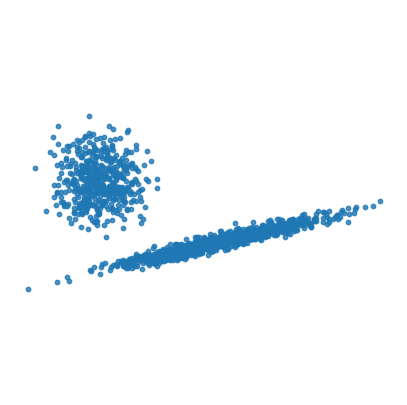

In [15]:
plt.figure(figsize=(5, 5))
plt.scatter(X[:, 0], X[:, 1], s = 10, alpha = 0.8)
plt.axis('equal')
plt.axis('off')
plt.show()

--- 


In [16]:
# Fit a mixture of Gaussians with EM using two components
import sklearn.mixture
gmm = sklearn.mixture.GaussianMixture(n_components=2, 
                                      covariance_type='full', 
                                      init_params = 'kmeans')
y_pred = gmm.fit_predict(X)

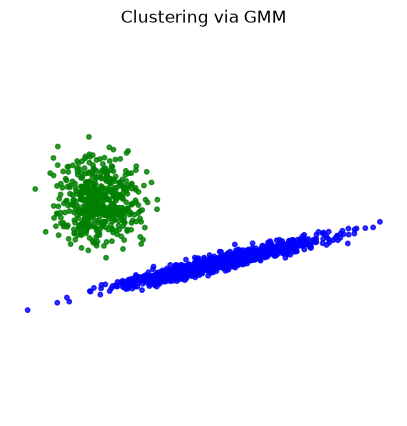

In [17]:
plt.figure(figsize=(5, 5))
colors = ['bg'[p] for p in y_pred]
plt.title('Clustering via GMM')
plt.axis('off')
plt.axis('equal')
plt.scatter(X[:, 0], X[:, 1], color = colors, s = 10, alpha = 0.8)
plt.show()

In [18]:
for clus in range(2):
    print(f'Cluster {clus}:')
    print(f' weight: {gmm.weights_[clus]:0.3f}')
    print(f' mean: {gmm.means_[clus]}')
    print(f' cov: \n{gmm.covariances_[clus]}\n')

Cluster 0:
 weight: 0.667
 mean: [-0.04719455 -0.00741777]
 cov: 
[[2.78299944 0.64624931]
 [0.64624931 0.16589271]]

Cluster 1:
 weight: 0.333
 mean: [-4.03209555  1.96770685]
 cov: 
[[ 0.46440554 -0.01263282]
 [-0.01263282  0.48113597]]



## Comparison with k-means


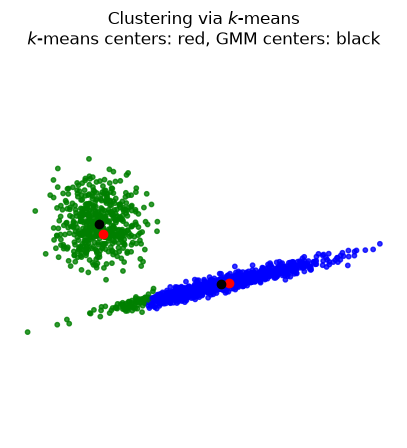

In [19]:
plt.figure(figsize=(5, 5))
import sklearn.cluster
kmeans = sklearn.cluster.KMeans(init = 'k-means++', n_clusters = 2, n_init = 100)
y_pred_kmeans = kmeans.fit_predict(X)
colors = ['bg'[p] for p in y_pred_kmeans]
plt.title('Clustering via $k$-means\n$k$-means centers: red, GMM centers: black')
plt.axis('off')
plt.axis('equal')
plt.scatter(X[:, 0], X[:, 1], color = colors, s = 10, alpha = 0.8)
plt.plot(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 'ro')
plt.plot(gmm.means_[:,0], gmm.means_[:, 1], 'ko')
plt.show()

In [20]:
for clus in range(2):
    print(f'Cluster {clus}:')
    print(f' center: {kmeans.cluster_centers_[clus]}\n')

Cluster 0:
 center: [0.20678138 0.04903169]

Cluster 1:
 center: [-3.91417527  1.61676661]



## Overlapping Clusters

Now, let's construct __overlapping__ clusters.  What will happen?

In [21]:
X = np.r_[(rng.standard_normal((n_samples, 2)) @ C),
          .7 * rng.standard_normal((n_samples//2, 2))]
gmm = sklearn.mixture.GaussianMixture(n_components=2, covariance_type='full')
y_pred_over = gmm.fit_predict(X)

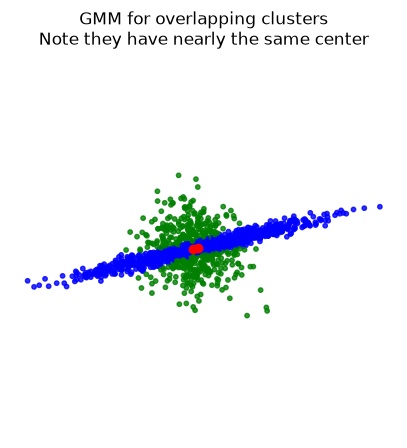

In [22]:
plt.figure(figsize=(5, 5))
colors = ['bgrky'[p] for p in y_pred_over]
plt.title('GMM for overlapping clusters\nNote they have nearly the same center')
plt.scatter(X[:, 0], X[:, 1], color = colors, s = 10, alpha = 0.8)
plt.axis('equal')
plt.axis('off')
plt.plot(gmm.means_[:,0], gmm.means_[:,1], 'ro')
plt.show()

In [23]:
for clus in range(2):
    print(f'Cluster {clus}:')
    print(f' weight: {gmm.weights_[clus]:0.3f}')
    print(f' mean: {gmm.means_[clus]}\n')
    # print(f' cov: \n{gmm.covariances_[clus]}\n')

Cluster 0:
 weight: 0.647
 mean: [0.10975427 0.0237165 ]

Cluster 1:
 weight: 0.353
 mean: [-0.02170599  0.0046345 ]



## How many parameters are estimated?

Most of the parameters in the model are contained in the covariance matrices.

In the most general case, for $K$ clusters of points in $d$ dimensions, there are $K$ covariance matrices each of size $d \times d$.   

So we need $Kd^2$ parameters to specify this model.

It can happen that you may not have enough data to estimate so many parameters.

Also, it can happen that you believe that clusters should have some constraints on their shapes.

Here is where the GMM assumptions become __really__ useful.

## Clusters with Equal Variance

Let's say you believe all the clusters should have the same shape, but the shape can be arbitrary. 

Then you only need to estimate __one__ covariance matrix - just $d^2$ parameters.

This is specified by the GMM parameter `covariance_type='tied'`.

In [24]:
X = np.r_[np.dot(rng.standard_normal((n_samples, 2)), C),
          0.7 * rng.standard_normal((n_samples, 2))]
gmm = sklearn.mixture.GaussianMixture(n_components=2, covariance_type='tied')
y_pred = gmm.fit_predict(X)

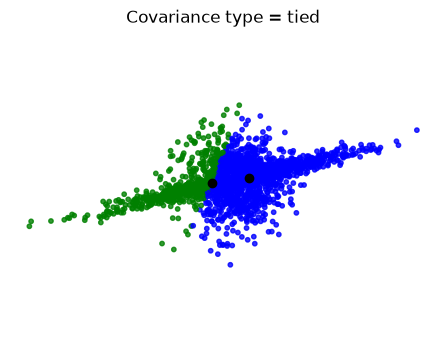

In [25]:
#| fig-align: 'center'
plt.figure(figsize=(5.5, 4))
colors = ['bgrky'[p] for p in y_pred]
plt.scatter(X[:, 0], X[:, 1], color=colors, s=10, alpha=0.8)
plt.title('Covariance type = tied')
plt.axis('equal')
plt.axis('off')
plt.plot(gmm.means_[:,0],gmm.means_[:,1], 'ok')
plt.show()

## Non-Skewed Clusters

Perhaps you believe in even more restricted shapes: all clusters should have their axes aligned with the coordinate axes.

That is, clusters are not skewed.

Then you only need to estimate the diagonals of the covariance matrices - just $Kd$ parameters.

This is specified by the GMM parameter `covariance_type='diag'`.

In [26]:
X = np.r_[np.dot(rng.standard_normal((n_samples, 2)), C),
          0.7 * rng.standard_normal((n_samples, 2))]
gmm = sklearn.mixture.GaussianMixture(n_components=4, covariance_type='diag')
y_pred = gmm.fit_predict(X)

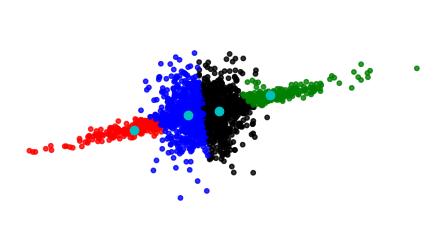

In [27]:
#| fig-align: 'center'
plt.figure(figsize=(5.5, 3))
colors = ['bgrky'[p] for p in y_pred]
plt.scatter(X[:, 0], X[:, 1], color = colors, s = 10, alpha = 0.8)
plt.axis('equal')
plt.axis('off')
plt.plot(gmm.means_[:,0], gmm.means_[:,1], 'oc')
plt.show()

## Round Clusters

Finally, if you believe that all clusters should be round, then you only need to estimate the $K$ variances.  

This is specified by the GMM parameter `covariance_type='spherical'`.

In [28]:
X = np.r_[np.dot(rng.standard_normal((n_samples, 2)), C),
          0.7 * rng.standard_normal((n_samples, 2))]
gmm = sklearn.mixture.GaussianMixture(n_components=2, covariance_type='spherical')
y_pred = gmm.fit_predict(X)

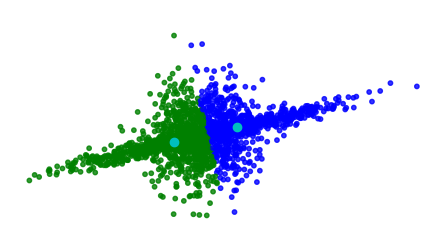

In [29]:
#| fig-align: 'center'
plt.figure(figsize=(5.5, 3))
colors = ['bgrky'[p] for p in y_pred]
plt.scatter(X[:, 0], X[:, 1], color = colors, s = 10, alpha = 0.8)
plt.axis('equal')
plt.axis('off')
plt.plot(gmm.means_[:,0], gmm.means_[:,1], 'oc')
plt.show()